We fit the paramters of the model by performing a maximum likelihood estimate with just the upcrossing data. Assuming given the level u, total time of recording T, number of datapoints n, and the time stamps of the upcrossings and the downcrossings. The question is to estimate the parameters of the process with OU-noise: tau_f, tau_f, sigma.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import scipy
import scipy.linalg
import gaussian_crossings.utils as utils
import gaussian_crossings.formula as formula
import gaussian_crossings.process as process

In [2]:
# Simulate the process
T = 10.0                         # Total simulation time.
tau_e = 0.06                    # Correlation decay parameter for the process.
tau_f = 0.005                   # Second correlation parameter.
dt = 0.05 * min(tau_e, tau_f)   # Time discretization step for simulation of the process.
sigma = 1.0                     # Standard deviation of the process.
u = 0.5                         # Threshold.
n = 1000                         # Number of trials

In [3]:
# Simulate the process and record the crossing times.
upcrossing_times = []
downcrossing_times = []

for i in range(n):
    t, x = utils.simulate_gaussian_process_fft(
        process.r_OU_noise, T, dt,
        sigma=sigma, tau=tau_e, kappa=tau_f/tau_e
    )
    upcrossing_times.append(utils.upcrossing_times(x=x, t=t, threshold=u))
    downcrossing_times.append(utils.downcrossing_times(x=x, t=t, threshold=u))

# --------------------------------------------------------------------
# Compute observed upcrossings count per trial
observed_counts = torch.tensor([len(times) for times in upcrossing_times], dtype=torch.float32)
# print("Observed counts:", observed_counts.tolist())

In [4]:
# functions to find the mean and variance of the upcrossing counts.
model = formula.GaussianUpCrossingsDimless(r_func=process.r_OU_noise, u=u, tau=tau_e, kappa=tau_f/tau_e, sigma=sigma)
mean_num_upcrossings = model.upcrossing_mean(T)
variance_num_upcrossings = model.upcrossing_variance(T)

# print the mean and variance of the upcrossing counts.
print(f"Mean number of upcrossings: {mean_num_upcrossings}")
print(f"Variance of the number of upcrossings: {variance_num_upcrossings}")

# print the numerical mean and variance of the upcrossing counts.
print(f"Numerical mean number of upcrossings: {observed_counts.mean()}")
print(f"Numerical variance of the number of upcrossings: {observed_counts.var()}")

Mean number of upcrossings: 18.09384939766383
Variance of the number of upcrossings: 30.702903656617874
Numerical mean number of upcrossings: 18.16900062561035
Numerical variance of the number of upcrossings: 32.3928337097168


Initial parameters:
tau_e: 0.6
tau_f: 0.05000000000000001
sigma: 2.0
Epoch    0: Loss = 12.3303, tau_e = 0.600000, tau_f = 0.050000, sigma = 2.000000
Epoch  100: Loss = 9.8250, tau_e = 0.545106, tau_f = 0.045336, sigma = 2.195740
Epoch  200: Loss = 8.0611, tau_e = 0.499931, tau_f = 0.041381, sigma = 2.373808
Epoch  300: Loss = 6.7694, tau_e = 0.461945, tau_f = 0.038046, sigma = 2.536533
Epoch  400: Loss = 5.8048, tau_e = 0.429587, tau_f = 0.035235, sigma = 2.685720
Epoch  500: Loss = 5.0800, tau_e = 0.401865, tau_f = 0.032862, sigma = 2.822218
Epoch  600: Loss = 4.5370, tau_e = 0.378093, tau_f = 0.030859, sigma = 2.946374
Epoch  700: Loss = 4.1339, tau_e = 0.357756, tau_f = 0.029168, sigma = 3.058288
Epoch  800: Loss = 3.8391, tau_e = 0.340450, tau_f = 0.027742, sigma = 3.157989
Epoch  900: Loss = 3.6276, tau_e = 0.325838, tau_f = 0.026542, sigma = 3.245555
Epoch 1000: Loss = 3.4793, tau_e = 0.313627, tau_f = 0.025535, sigma = 3.321187
Epoch 1100: Loss = 3.3779, tau_e = 0.303555, tau_f

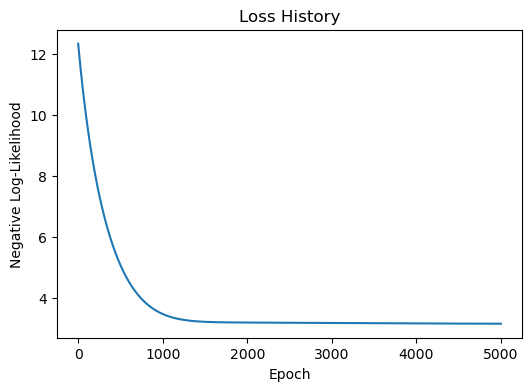

In [9]:
# Set up parameters for optimization.
# We optimize log parameters so that the exponentiated values remain positive.
# log_tau_e = torch.tensor(np.log(tau_e), dtype=torch.float64, requires_grad=True)
# log_tau_f = torch.tensor(np.log(tau_f), dtype=torch.float64, requires_grad=True)
# log_sigma = torch.tensor(np.log(sigma), dtype=torch.float64, requires_grad=True)

log_tau_e = torch.tensor(np.log(0.6), dtype=torch.float64, requires_grad=True)
log_tau_f = torch.tensor(np.log(0.05), dtype=torch.float64, requires_grad=True)
log_sigma = torch.tensor(np.log(2.0), dtype=torch.float64, requires_grad=True)


# print the intial parameters
print("Initial parameters:")
print(f"tau_e: {torch.exp(log_tau_e).item()}")
print(f"tau_f: {torch.exp(log_tau_f).item()}")
print(f"sigma: {torch.exp(log_sigma).item()}")


# Choose an optimizer
optimizer = torch.optim.Adam([log_tau_e, log_tau_f, log_sigma], lr=1e-3)

# For tracking the loss history
num_epochs = 5000
loss_history = []

# --------------------------------------------------------------------
# Optimization loop
for epoch in range(num_epochs):
    optimizer.zero_grad()
    
    # Convert log parameters to actual parameters ensuring positivity.
    tau_e_est = torch.exp(log_tau_e)
    tau_f_est = torch.exp(log_tau_f)
    sigma_est = torch.exp(log_sigma)
    kappa_est = tau_f_est / tau_e_est  # kappa is defined as tau_f/tau_e.
    
    # Create a model instance with the current estimates.
    model_est = formula.GaussianUpCrossingsDimless(
        r_func=process.r_OU_noise, u=u, tau=tau_e_est, kappa=kappa_est, sigma=sigma_est
    )
    
    # Compute the predicted mean and variance for the number of upcrossings over time T.
    mean_est = model_est.upcrossing_mean(T)
    var_est = model_est.upcrossing_variance(T)
    
    # Define the negative log likelihood assuming a Gaussian likelihood for the counts.
    # For each trial, NLL = 0.5*log(2*pi*var) + 0.5*(observed - mean)^2 / var.
    nll = 0.5 * torch.log(2 * torch.pi * var_est) + 0.5 * ((observed_counts - mean_est)**2) / var_est
    loss = nll.mean()  # Sum over all trials.
    
    # Backpropagate the loss.
    loss.backward()
    optimizer.step()
    
    loss_history.append(loss.item())
    
    if epoch % 100 == 0:
        print(f"Epoch {epoch:4d}: Loss = {loss.item():.4f}, "
              f"tau_e = {tau_e_est.item():.6f}, tau_f = {tau_f_est.item():.6f}, sigma = {sigma_est.item():.6f}")

print("Optimization complete!")
print("Estimated parameters:")
print(f"tau_e: {torch.exp(log_tau_e).item()}")
print(f"tau_f: {torch.exp(log_tau_f).item()}")
print(f"sigma: {torch.exp(log_sigma).item()}")

# Optional: Plot loss history
plt.figure(figsize=(6, 4))
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Negative Log-Likelihood")
plt.title("Loss History")
plt.show()

In [10]:
# print the anaytical mean and variance with true paramters and learned paramteres
print("Analytical mean and variance with true parameters:")
print(f"Mean number of upcrossings: {mean_num_upcrossings}")
print(f"Variance of the number of upcrossings: {variance_num_upcrossings}")


print("Analytical mean and variance with estimated parameters:")
model_est = formula.GaussianUpCrossingsDimless(r_func=process.r_OU_noise, u=u, tau=tau_e_est, kappa=kappa_est, sigma=sigma_est)
mean_num_upcrossings_est = model_est.upcrossing_mean(T)
variance_num_upcrossings_est = model_est.upcrossing_variance(T)
print(f"Mean number of upcrossings (estimated): {mean_num_upcrossings_est}")
print(f"Variance of the number of upcrossings (estimated): {variance_num_upcrossings_est}")

Analytical mean and variance with true parameters:
Mean number of upcrossings: 18.09384939766383
Variance of the number of upcrossings: 30.702903656617874
Analytical mean and variance with estimated parameters:
Mean number of upcrossings (estimated): 18.222981847282142
Variance of the number of upcrossings (estimated): 28.46776799997013
